In [22]:
# Membres : Prénom1, Prénom2, Prénom3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
CSV_PATH = "0_z.csv"          # adapter le chemin si besoin
EPOCH_LENGTHS = [10, 30, 60]  # durées d'époque en secondes
def load_data(path:str):
    """Charge le CSV brut (colonnes : t, x, y, z) et le trie par temps."""
    df = pd.read_csv(path, comment="#")
    df = df.sort_values("t").reset_index(drop=True)
    return df

def compute_enmo(df, truncate=True):
    """ENMO = norme du vecteur (x, y, z) - 1 g. Si truncate=True, les valeurs négatives sont ramenées à 0."""
    df = df.copy()
    norm = np.sqrt(df["x"]**2 + df["y"]**2 + df["z"]**2)
    enmo = norm - 1.0
    df["enmo"] = enmo
    #df["enmo"] = enmo.clip(lower=0) if truncate else enmo
    return df

In [24]:
def integrate_enmo(df, epoch_s):
    """
    Intègre l'ENMO sur des époques de epoch_s secondes.
    Résultat en g·min : somme(enmo * dt) / 60.
    """
    dt = df["t"].diff().median()               # pas d'échantillonnage (s)
    t0 = df["t"].iloc[0]
    epoch_idx = ((df["t"] - t0) // epoch_s).astype(int)

    integrated = (df["enmo"] * dt).groupby(epoch_idx).sum() / 60.0
    epochs_df = pd.DataFrame({
        "epoch_start": integrated.index * epoch_s,
        "enmo_integre": integrated.values,
    })
    return epochs_df

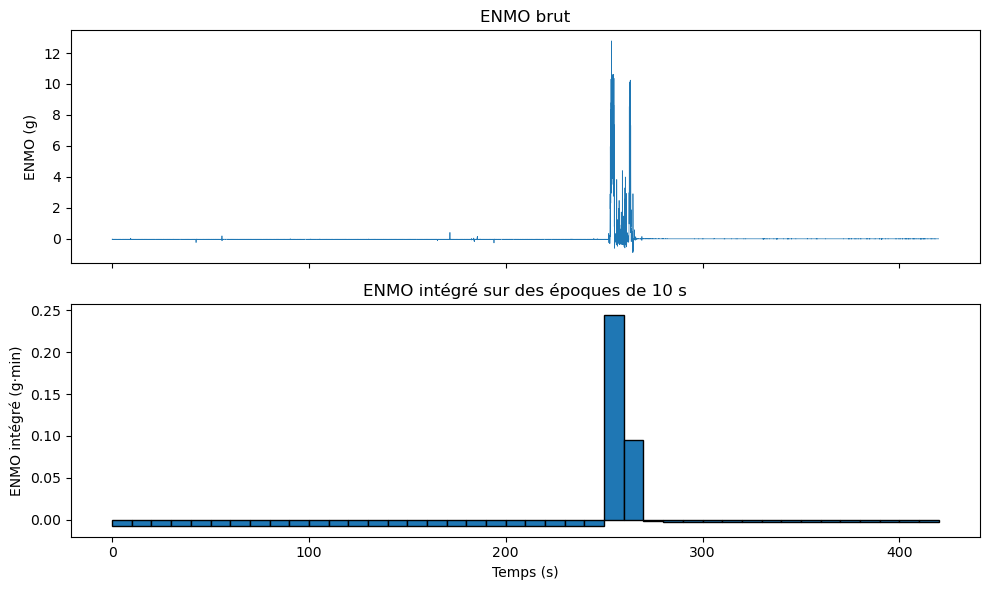

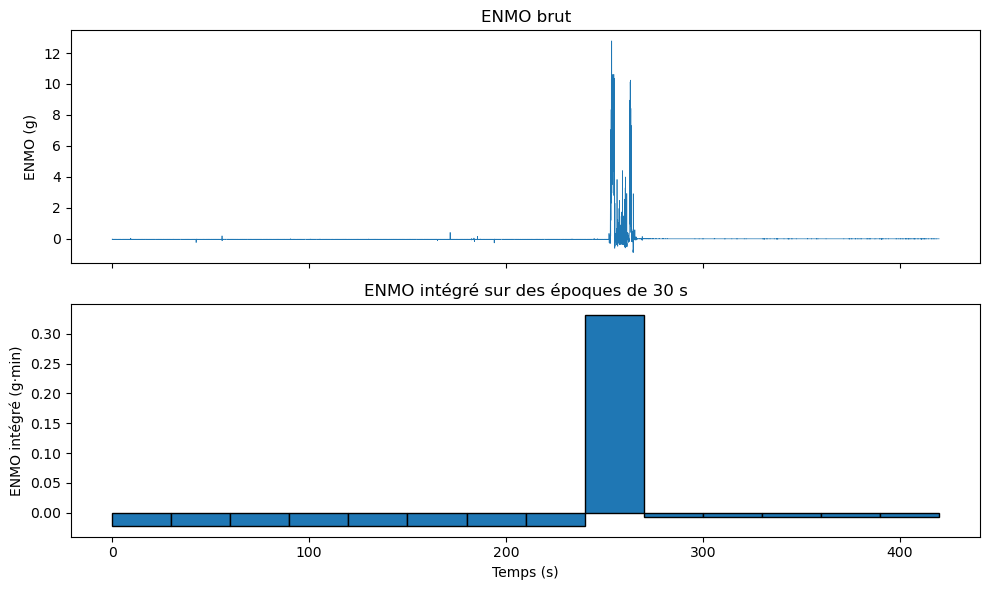

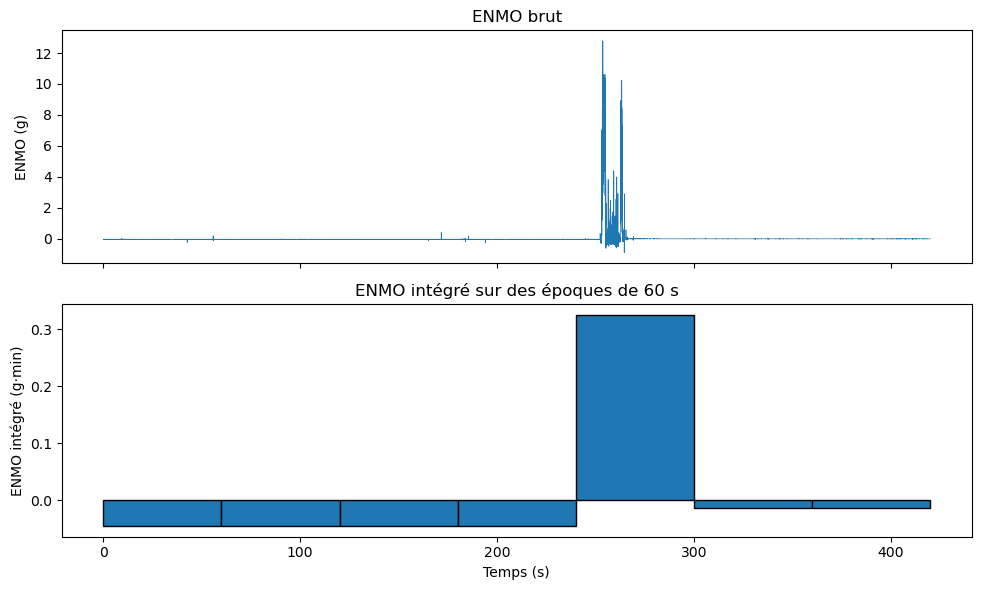

In [25]:
def plot_enmo(df, epochs_df, epoch_s):
    """Figure à 2 graphiques : ENMO brut, puis ENMO intégré par époque."""
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    axes[0].plot(df["t"], df["enmo"], lw=0.5)
    axes[0].set_ylabel("ENMO (g)")
    axes[0].set_title(f"ENMO brut")

    axes[1].bar(epochs_df["epoch_start"], epochs_df["enmo_integre"],
                width=epoch_s, align="edge", edgecolor="k")
    axes[1].set_ylabel("ENMO intégré (g·min)")
    axes[1].set_xlabel("Temps (s)")
    axes[1].set_title(f"ENMO intégré sur des époques de {epoch_s} s")

    plt.tight_layout()
    plt.show()


def run_all(path, epoch_lengths=(10, 30, 60)):
    df = compute_enmo(load_data(path))
    for epoch_s in epoch_lengths:
        epochs_df = integrate_enmo(df, epoch_s)
        plot_enmo(df, epochs_df, epoch_s)


run_all("../data/0_z.csv")

In [26]:
import os
print("Current directory:", os.getcwd())
print("Contents:", os.listdir("."))

Current directory: c:\Users\jerob\OneDrive\Bureau\SNS\M2\Santé_activité_physique\Denis_mottet\My-Projects\HAH913E-Physical-activity-00-Assignment\notebooks
Contents: ['ENMO.ipynb', 'enmo_notebook v2.ipynb']
